#**1. Display the first 10 rows of the dataset.**


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv("projects.csv")
df.head(10)

,project_id,company_id,project_name,start_date,completion_date,project_status,automation_type,robots_deployed,budget_usd,annual_savings_usd,roi_percent,department,implementation_partner,country,industry,employee_hours_saved,ai_enabled,cloud_deployment
0,PRJ000001,CMP04872,Prism Automation Initiative,2017-04-23,NaN,Active,Customer Onboarding,27,10889,17248,158.4,Content Moderation,Cyient,Vietnam,Government & Public Sector,69944,Yes,Yes
1,PRJ000002,CMP04395,Sentinel Process Reengineering,2023-07-29,2024-03-16,Completed,Claims Processing,44,1069470,579652,54.2,Customer Onboarding,Tech Mahindra,South Africa,Mining & Metals,31856,No,Yes
2,PRJ000003,CMP01477,Sentinel Task Automation,2021-03-10,2022-12-22,Completed,Email Automation,18,43509,23494,54.0,Finance & Accounting,EXL Service,United States,Nonprofit & NGO,5935,No,Yes
3,PRJ000004,CMP00578,Robust Automation Platform,2023-12-30,2024-12-15,Completed,Order Processing,6,99001,107812,108.9,Finance & Accounting,Birlasoft,Italy,Banking & Financial Services,9491,Yes,Yes
4,PRJ000005,CMP02586,Nexus Automation Platform,2024-09-08,NaN,Active,Customer Onboarding,21,122055,255949,209.7,Sales & Marketing,Capgemini,Denmark,Aerospace & Defense,26693,Yes,Yes
5,PRJ000006,CMP00868,Phantom Workforce Digitization,2017-06-18,2018-02-28,Completed,HR Onboarding,14,121789,547928,449.9,Fraud Detection,Tata Consultancy Services,New Zealand,Professional Services & Consulting,81217,No,Yes
6,PRJ000007,CMP01179,Unified Hyperautomation,2020-08-19,2020-10-07,Completed,IT Helpdesk,36,425952,2129760,500.0,IT & Technology,Aricent,United Kingdom,Insurance,411719,No,Yes
7,PRJ000008,CMP00683,Apex Bot Operations,2023-02-16,2024-08-12,Completed,Process Automation,31,220550,451024,204.5,Data Entry,HCL Technologies,Malaysia,Life Sciences,72462,Yes,Yes
8,PRJ000009,CMP02316,Scalable Task Automation,2024-07-08,NaN,Active,Data Extraction & Migration,38,54618,74444,136.3,Inventory Management,EXL Service,Poland,Aerospace & Defense,82296,Yes,Yes
9,PRJ000010,CMP00730,Streamlined Operational Excellence,2015-05-26,NaN,Active,Inventory Management,6,81069,171785,211.9,Order Processing,Maveric Systems,India,Transportation & Logistics,3879,Yes,Yes


#**2.Find the number of rows and columns.**

In [6]:
df.shape

(50000, 18)

#**3. Show the data types of all columns.**

In [7]:
df.dtypes

,0
project_id,object
company_id,object
project_name,object
start_date,object
completion_date,object
project_status,object
automation_type,object
robots_deployed,int64
budget_usd,int64
annual_savings_usd,int64


#**4. Check missing values in each column.**

In [8]:
df.isnull().sum()

,0
project_id,0
company_id,0
project_name,0
start_date,0
completion_date,14936
project_status,0
automation_type,0
robots_deployed,0
budget_usd,0
annual_savings_usd,0


#**5. How many projects belong to each project status?**

In [9]:
df['project_status'].value_counts()

,count
project_status,
Completed,27681
Active,14936
Planned,7383


#**6. Top 10 countries by number of projects**

In [10]:
df['country'].value_counts().head(10)

,count
country,
United States,5303
India,3472
United Kingdom,3018
Germany,2205
China,1990
Japan,1951
France,1620
Canada,1453
South Korea,1245


#**7.Find Projects Saving More Than the Average Hours**

In [11]:
avg_hours = np.mean(df['employee_hours_saved'])

(df['employee_hours_saved'] > avg_hours).sum()

np.int64(17375)

#**8. Calculate Total Budget, Total Annual Savings, and Average ROI for each industry.**

In [26]:
industry_performance = df.groupby('industry').agg({'budget_usd':'sum','annual_savings_usd':'sum','roi_percent':'mean'
}).round(2)
industry_performance

,budget_usd,annual_savings_usd,roi_percent
industry,,,
Aerospace & Defense,395186613,733273425,177.59
Agriculture & Food Processing,347597786,629187967,174.95
Automotive,363874020,619574369,172.08
Banking & Financial Services,387851366,676058041,175.50
Chemical & Materials,389112260,680869724,176.89
Construction & Engineering,348820334,629254328,177.79
Education,423616335,774605596,174.74
Energy & Utilities,314098330,528535666,168.58
FMCG & Consumer Goods,337534379,556911197,169.07


#**9. Count Projects in Each ROI Category**

In [13]:
low = np.sum(df['roi_percent'] < 50)
medium = np.sum((df['roi_percent'] >= 50) &(df['roi_percent'] <= 100))
high = np.sum(df['roi_percent'] > 100)
print("Low:", low)
print("Medium:", medium)
print("High:", high)

Low: 1811
Medium: 11018
High: 37171


#**10. Calculate the Mean ,Median,Maximum,Medium,Standard Deviation Budget**

In [14]:
np.mean(df['budget_usd'])
np.median(df['budget_usd'])
np.max(df['budget_usd'])
np.min(df['budget_usd'])
np.std(df['budget_usd'])

255851.9701901644

#**11. Create a bar chart showing the number of projects in each project status.**

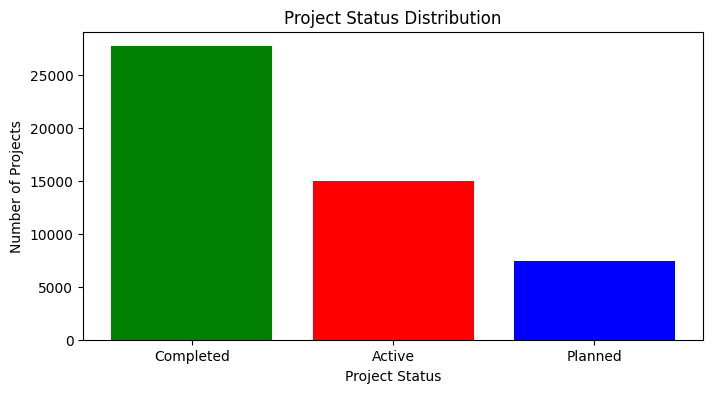

In [25]:
import matplotlib.pyplot as plt
status_count = df['project_status'].value_counts()
plt.figure(figsize=(8,4))
plt.bar(status_count.index, status_count.values,color=(["green","red","blue"]))
plt.title('Project Status Distribution')
plt.xlabel('Project Status')
plt.ylabel('Number of Projects')
plt.show()

#**12. Plot Budget vs Annual Savings**

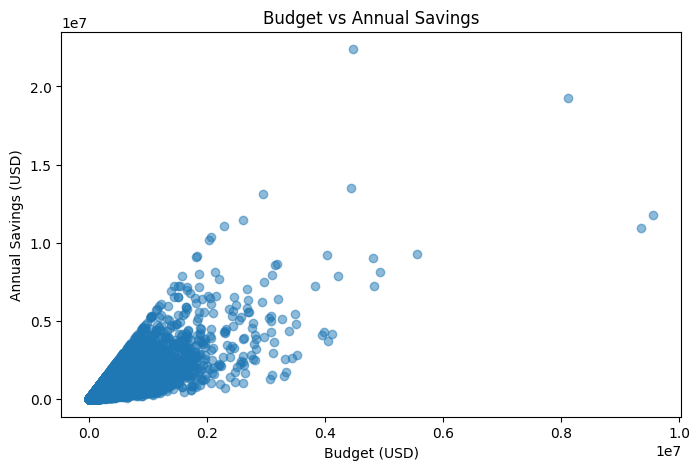

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(
    df['budget_usd'],
    df['annual_savings_usd'],
    alpha=0.5
)
plt.title('Budget vs Annual Savings')
plt.xlabel('Budget (USD)')
plt.ylabel('Annual Savings (USD)')
plt.show()

#**13.Create a horizontal bar chart showing average ROI by industry.**

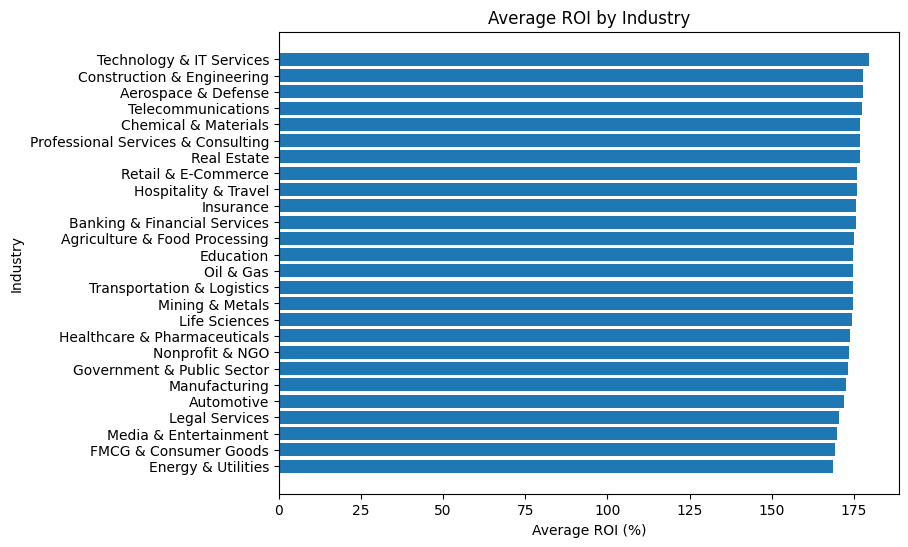

In [17]:
industry_roi = df.groupby('industry')['roi_percent'].mean()
industry_roi = industry_roi.sort_values()
plt.figure(figsize=(8,6))
plt.barh(industry_roi.index,
    industry_roi.values
)
plt.title('Average ROI by Industry')
plt.xlabel('Average ROI (%)')
plt.ylabel('Industry')
plt.show()

#**14. Histogram of Budget Distribution**

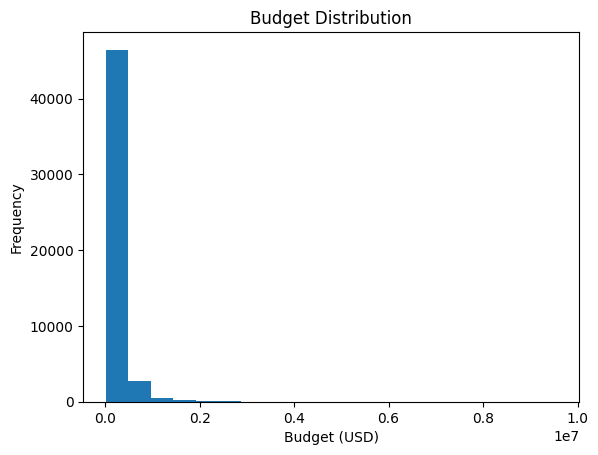

In [18]:
plt.hist(df['budget_usd'], bins=20)
plt.title('Budget Distribution')
plt.xlabel('Budget (USD)')
plt.ylabel('Frequency')
plt.show()

#**15. Pie Chart of Project Status**

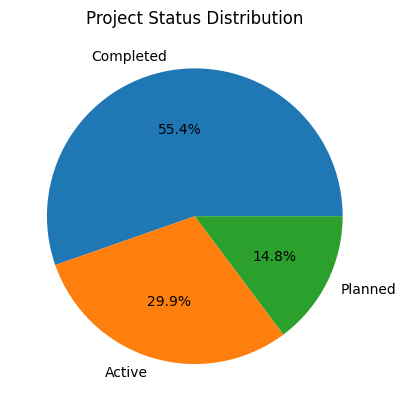

In [19]:
status = df['project_status'].value_counts()
plt.pie(status.values, labels=status.index,autopct='%1.1f%%')
plt.title('Project Status Distribution')
plt.show()

#**16. Line Chart of Average Budget by Industry**

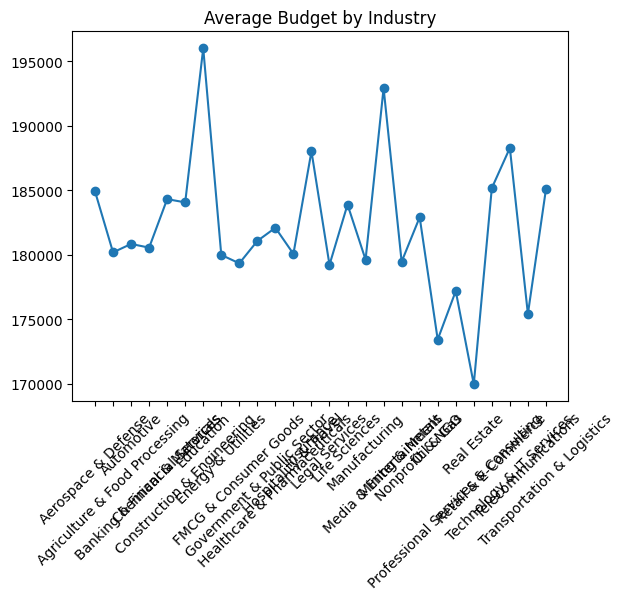

In [20]:
avg_budget = df.groupby('industry')['budget_usd'].mean()
plt.plot(avg_budget.index, avg_budget.values, marker='o')
plt.xticks(rotation=45)
plt.title('Average Budget by Industry')
plt.show()

#**17. Correlation Heatmap**

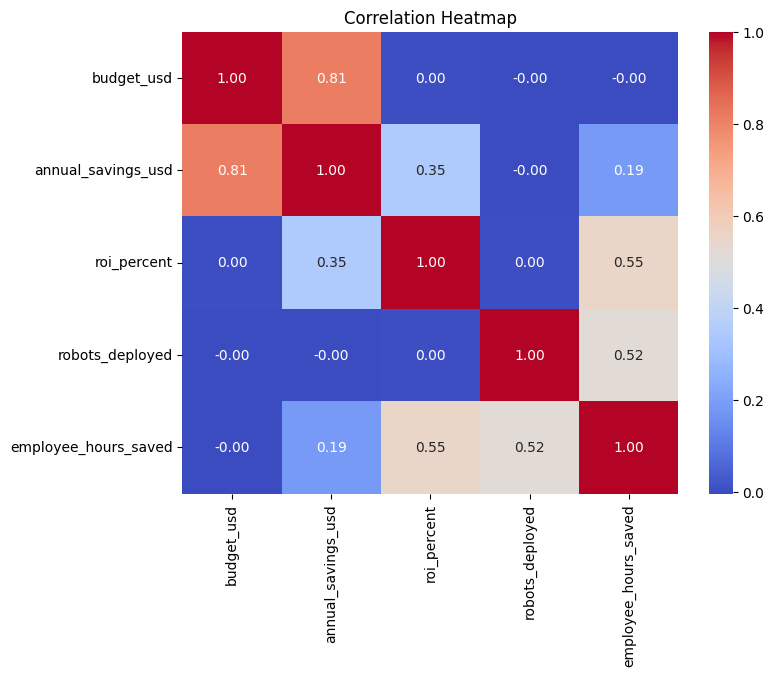

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df[['budget_usd', 'annual_savings_usd','roi_percent','robots_deployed','employee_hours_saved']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

#**18. Distribution of Budget using Seaborn**

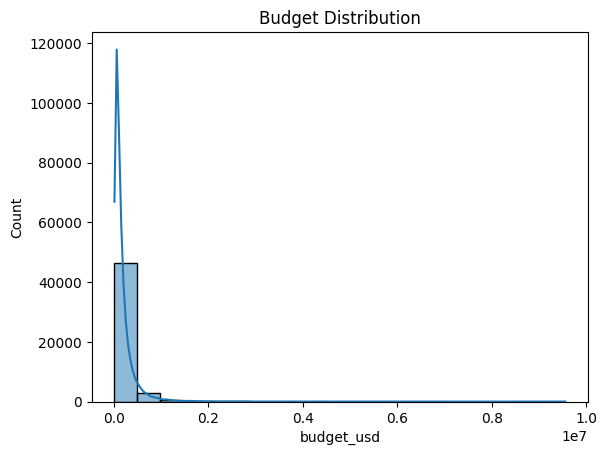

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['budget_usd'], bins=20, kde=True)
plt.title('Budget Distribution')
plt.show()

#**19. Boxplot of Budget by Industry**

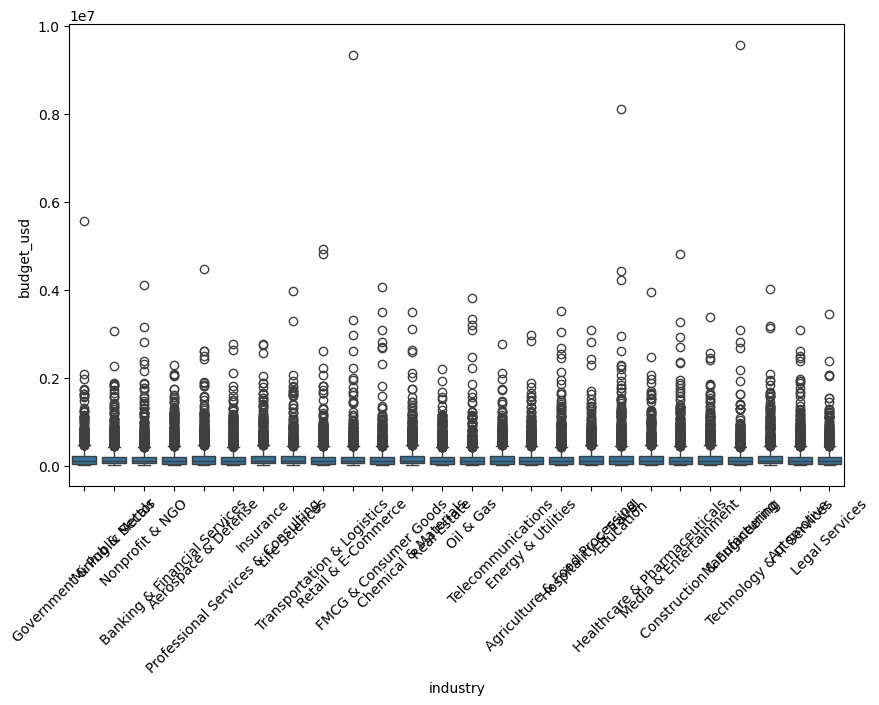

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(x='industry', y='budget_usd', data=df)
plt.xticks(rotation=45)
plt.show()

#**20. Department-wise Savings Comparison**

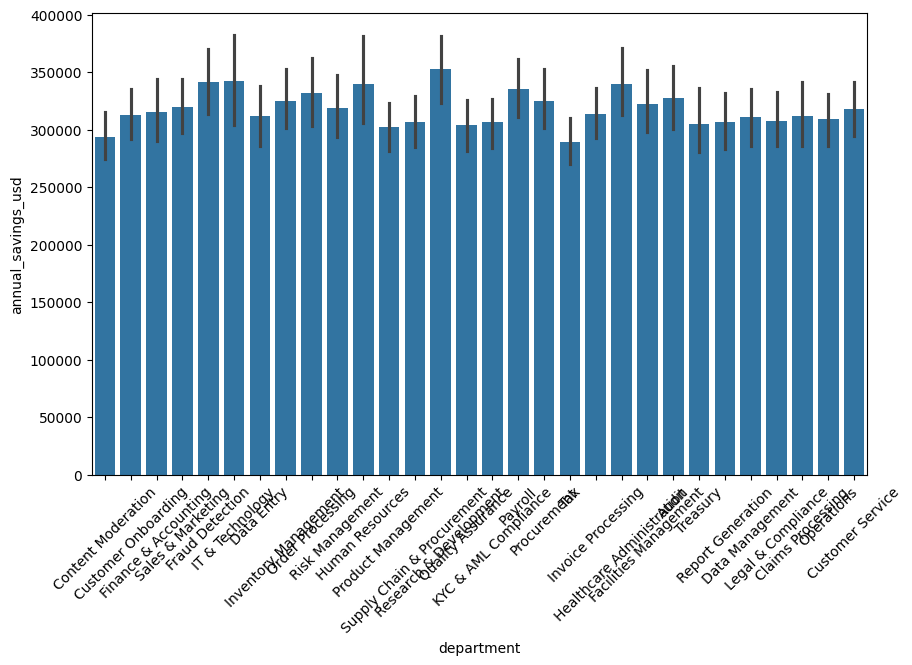

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(x='department', y='annual_savings_usd',data=df)
plt.xticks(rotation=45)
plt.show()